In [11]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

# Tarefa 2: Modelos com Implementação Própria (NumPy)

Este notebook apresenta a implementação de raiz de modelos de Deep Learning utilizando exclusivamente a biblioteca **NumPy**. O objetivo é classificar textos entre 5 classes distintas: **Google, Human, Meta, Mistral e OpenAI**.

De acordo com os requisitos do enunciado, exploramos uma abordagem de implementação manual para compreender os fundamentos de *Backpropagation* e otimização de redes neuronais.

## 1. Preparação dos Dados e Engenharia de Features

Nesta fase, convertemos o texto bruto em representações numéricas tabulares.
* **Vetorização:** Utilizamos **TF-IDF** (Term Frequency-Inverse Document Frequency) com um limite de 2000 features.
* **Codificação:** As labels foram convertidas para **One-Hot Encoding**, permitindo o uso da função de perda *Categorical Cross-Entropy*.
* **Dataset Customizado:** Criámos uma classe `TextDataset` para organizar os dados de treino e teste de forma modular.

In [12]:
# Passo 1: Preparar os 2 Datasets no Pandas
df = pd.read_csv('../data/dataset_final2.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

X = df['Text']
y = df['Label']

print("Distribuição total:")
print(df['Label'].value_counts())

# 1. Dataset para o Modelo 1 (Binário e Equilibrado)
df_human = df[df['Label'] == 'Human']

# Agrupar as IAs e extrair 250 de cada (250 * 4 = 1000 IAs, perto dos 1000 Humanos)
# Como Anthropic, Google, Meta e OpenAI têm números diferentes, garantimos as 105
df_ai_balanced = df[df['Label'] != 'Human'].groupby('Label').sample(n=250, random_state=42)

df_model1 = pd.concat([df_human, df_ai_balanced]).sample(frac=1, random_state=42) # Juntar e baralhar
df_model1['Label_Bin'] = np.where(df_model1['Label'] == 'Human', 'Human', 'IA')

# 2. Dataset para o Modelo 2 (Apenas IA, Multiclasse)
df_model2 = df[df['Label'] != 'Human']

# Obter as classes para uso futuro
classes1 = pd.get_dummies(df_model1['Label_Bin']).columns
classes2 = pd.get_dummies(df_model2['Label']).columns


Distribuição total:
Label
Human        999
Google       999
Meta         999
Anthropic    999
OpenAI       998
Name: count, dtype: int64


In [13]:
# Passo 2: Criar as Divisões e os TF-IDFs Independentes

# --- Setup do Modelo 1 (IA vs Humano) ---
X1 = df_model1['Text']
y1_encoded = pd.get_dummies(df_model1['Label_Bin']).astype(int).values

X1_train, X1_temp, y1_train, y1_temp = train_test_split(X1, y1_encoded, test_size=0.2, random_state=42, stratify=y1_encoded)
X1_val, X1_test, y1_val, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.5, random_state=42, stratify=y1_temp)

tfidf1 = TfidfVectorizer(max_features=400, min_df=0.05,max_df=0.80, ngram_range=(1,2))
X1_train_tfidf = tfidf1.fit_transform(X1_train).toarray()
X1_val_tfidf = tfidf1.transform(X1_val).toarray()
X1_test_tfidf = tfidf1.transform(X1_test).toarray()

print(f"Modelo 1 - Treino: {X1_train_tfidf.shape[0]}, Val: {X1_val_tfidf.shape[0]}, Teste: {X1_test_tfidf.shape[0]}")

# --- Setup do Modelo 2 (Qual é a IA?) ---
X2 = df_model2['Text']
y2_encoded = pd.get_dummies(df_model2['Label']).astype(int).values

X2_train, X2_temp, y2_train, y2_temp = train_test_split(X2, y2_encoded, test_size=0.2, random_state=42, stratify=y2_encoded)
X2_val, X2_test, y2_val, y2_test = train_test_split(X2_temp, y2_temp, test_size=0.5, random_state=42, stratify=y2_temp)

tfidf2 = TfidfVectorizer(max_features=400, min_df=0.05,max_df=0.80, ngram_range=(1,2))
X2_train_tfidf = tfidf2.fit_transform(X2_train).toarray()
X2_val_tfidf = tfidf2.transform(X2_val).toarray()
X2_test_tfidf = tfidf2.transform(X2_test).toarray()

print(f"Modelo 2 - Treino: {X2_train_tfidf.shape[0]}, Val: {X2_val_tfidf.shape[0]}, Teste: {X2_test_tfidf.shape[0]}")


Modelo 1 - Treino: 1599, Val: 200, Teste: 200
Modelo 2 - Treino: 3196, Val: 399, Teste: 400


In [14]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset1 = TextDataset(X1_train_tfidf, y1_train)
val_dataset1 = TextDataset(X1_val_tfidf, y1_val)
test_dataset1 = TextDataset(X1_test_tfidf, y1_test)

train_dataset2 = TextDataset(X2_train_tfidf, y2_train)
val_dataset2 = TextDataset(X2_val_tfidf, y2_val)
test_dataset2 = TextDataset(X2_test_tfidf, y2_test)


In [15]:
# 1. Baseline para o Modelo Binário (Humano vs IA)
# Numa rede neural, Regressão Logística = 0 camadas ocultas

n_features1 = X1_train_tfidf.shape[1]
n_features2 = X2_train_tfidf.shape[1]

baseline1 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
# Ligar os inputs dinâmicos diretamente aos 2 outputs ('Human' e 'IA')
baseline1.add(DenseLayer(2, input_shape=(n_features1,))) 
baseline1.add(SoftmaxActivation())

print("--- A Treinar Baseline 1: Regressão Logística (Humano vs IA) ---")
baseline1.fit(train_dataset1, val_dataset=val_dataset1)

# 2. Baseline para o Modelo Multiclasse (Qual é a IA?)
# Matematicamente, isto chama-se "Softmax Regression" (Regressão Logística para Multiclasse)
baseline2 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
# Ligar os inputs dinâmicos diretamente aos 4 outputs (As 4 marcas de IA)
baseline2.add(DenseLayer(4, input_shape=(n_features2,))) 
baseline2.add(SoftmaxActivation())

print("\n--- A Treinar Baseline 2: Regressão Logística Multiclasse (IAs) ---")
baseline2.fit(train_dataset2, val_dataset=val_dataset2)

# =====================================================================
# AVALIAÇÃO DA BASELINE 1 NOS EXEMPLOS DO PROFESSOR (Corrigido!)
# =====================================================================
print("\nAVALIAÇÃO DA BASELINE 1 NOS EXEMPLOS DO PROFESSOR:")

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, matthews_corrcoef

# Carregar os dados de teste do professor diretamente aqui
df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_exemplos = df_exemplos.dropna(subset=['Text', 'Label'])
X_ex = df_exemplos['Text']

# Criar as labels binárias
y_ex_bin = np.where(df_exemplos['Label'] == 'Human', 'Human', 'IA')

# Transformar o texto com o novo TF-IDF
X_ex_tfidf1_novo = tfidf1.transform(X_ex).toarray()

# Criar o dataset com as dimensões certas
dummy_y_ex1_novo = np.zeros((len(X_ex), len(classes1)))
ds_ex1_novo = TextDataset(X_ex_tfidf1_novo, dummy_y_ex1_novo)

# Prever e calcular
y_pred_prob_base1 = baseline1.predict(ds_ex1_novo) 
preds_base1_bin = [classes1[np.argmax(p)] for p in y_pred_prob_base1]

acc_base1 = accuracy_score(y_ex_bin, preds_base1_bin)
mcc_base1 = matthews_corrcoef(y_ex_bin, preds_base1_bin)

print(f"Accuracy Baseline Binária: {acc_base1*100:.2f}%")
print(f"MCC Baseline Binária:      {mcc_base1:.4f}")

--- A Treinar Baseline 1: Regressão Logística (Humano vs IA) ---
Epoch 1/100 - loss: 0.7068 - val_loss: 0.6806 - accuracy: 0.5278
Epoch 10/100 - loss: 0.6392 - val_loss: 0.6225 - accuracy: 0.6642
Epoch 20/100 - loss: 0.5800 - val_loss: 0.5724 - accuracy: 0.7567
Epoch 30/100 - loss: 0.5341 - val_loss: 0.5339 - accuracy: 0.8143
Epoch 40/100 - loss: 0.4978 - val_loss: 0.5034 - accuracy: 0.8368
Epoch 50/100 - loss: 0.4683 - val_loss: 0.4790 - accuracy: 0.8618
Epoch 60/100 - loss: 0.4440 - val_loss: 0.4590 - accuracy: 0.8687
Epoch 70/100 - loss: 0.4236 - val_loss: 0.4423 - accuracy: 0.8718
Epoch 80/100 - loss: 0.4061 - val_loss: 0.4283 - accuracy: 0.8849
Epoch 90/100 - loss: 0.3911 - val_loss: 0.4161 - accuracy: 0.8881
Epoch 100/100 - loss: 0.3779 - val_loss: 0.4056 - accuracy: 0.8906

--- A Treinar Baseline 2: Regressão Logística Multiclasse (IAs) ---
Epoch 1/100 - loss: 1.4191 - val_loss: 1.3943 - accuracy: 0.2472
Epoch 10/100 - loss: 1.3418 - val_loss: 1.3220 - accuracy: 0.3617
Epoch 20/

## 2. Abordagem Dividir para Conquistar (DNNs)

In [16]:
# Passo 3: Ajustar as Camadas de Saída das Redes Neurais
# mcc

# Rede 1 (Binária)
net1 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
net1.add(DenseLayer(64, input_shape=(n_features1,)))
net1.add(ReLUActivation())
net1.add(DropoutLayer(0.2))
net1.add(DenseLayer(2)) 
net1.add(SoftmaxActivation())


print("--- Treinando Modelo 1 (Humano vs IA) ---")
net1.fit(train_dataset1, val_dataset=val_dataset1)


--- Treinando Modelo 1 (Humano vs IA) ---
Epoch 1/100 - loss: 0.7855 - val_loss: 0.7507 - accuracy: 0.4991
Epoch 10/100 - loss: 0.5665 - val_loss: 0.5787 - accuracy: 0.7523
Epoch 20/100 - loss: 0.4514 - val_loss: 0.4724 - accuracy: 0.8399
Epoch 30/100 - loss: 0.3849 - val_loss: 0.4052 - accuracy: 0.8768
Epoch 40/100 - loss: 0.3267 - val_loss: 0.3653 - accuracy: 0.8968
Epoch 50/100 - loss: 0.2920 - val_loss: 0.3392 - accuracy: 0.9056
Epoch 60/100 - loss: 0.2686 - val_loss: 0.3234 - accuracy: 0.9143
Epoch 70/100 - loss: 0.2545 - val_loss: 0.3120 - accuracy: 0.9250
Epoch 80/100 - loss: 0.2426 - val_loss: 0.3046 - accuracy: 0.9350
Epoch 90/100 - loss: 0.2132 - val_loss: 0.2956 - accuracy: 0.9387
Epoch 100/100 - loss: 0.2035 - val_loss: 0.2937 - accuracy: 0.9443


In [17]:
# Rede 2 (Multiclasse IA)
net2 = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
net2.add(DenseLayer(64, input_shape=(n_features2,)))
net2.add(ReLUActivation())
net2.add(DropoutLayer(0.2))
net2.add(DenseLayer(4)) 
net2.add(SoftmaxActivation())

print("--- Treinando Modelo 2 (Classificação de IAs) ---")
net2.fit(train_dataset2, val_dataset=val_dataset2)


--- Treinando Modelo 2 (Classificação de IAs) ---
Epoch 1/200 - loss: 1.4188 - val_loss: 1.3738 - accuracy: 0.3085
Epoch 10/200 - loss: 1.1908 - val_loss: 1.1636 - accuracy: 0.5541
Epoch 20/200 - loss: 1.0062 - val_loss: 0.9569 - accuracy: 0.6799
Epoch 30/200 - loss: 0.8720 - val_loss: 0.7987 - accuracy: 0.7369
Epoch 40/200 - loss: 0.7586 - val_loss: 0.6946 - accuracy: 0.7778
Epoch 50/200 - loss: 0.6565 - val_loss: 0.6259 - accuracy: 0.8088
Epoch 60/200 - loss: 0.6141 - val_loss: 0.5755 - accuracy: 0.8267
Epoch 70/200 - loss: 0.5665 - val_loss: 0.5395 - accuracy: 0.8407
Epoch 80/200 - loss: 0.5288 - val_loss: 0.5161 - accuracy: 0.8495
Epoch 90/200 - loss: 0.4905 - val_loss: 0.4953 - accuracy: 0.8573
Epoch 100/200 - loss: 0.4682 - val_loss: 0.4825 - accuracy: 0.8673
Epoch 110/200 - loss: 0.4409 - val_loss: 0.4715 - accuracy: 0.8758
Epoch 120/200 - loss: 0.4292 - val_loss: 0.4738 - accuracy: 0.8839
Epoch 130/200 - loss: 0.4079 - val_loss: 0.4637 - accuracy: 0.8889
Epoch 140/200 - loss: 0

A fazer previsões globais usando o pipeline...

Accuracy Global do Pipeline D&C: 85.18%


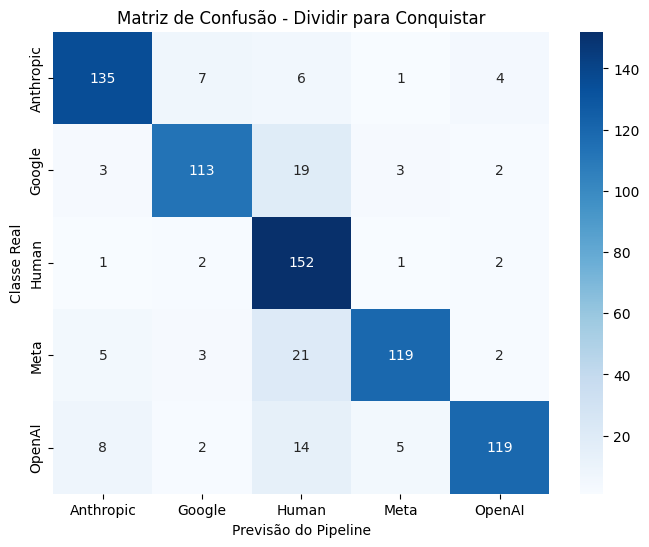

In [18]:
# Passo 4: A Lógica de Avaliação (Pipeline Final)

def pipeline_predict(texts, tfidf1, net1, tfidf2, net2, classes1, classes2):
    predictions = []
    
    # Textos vetorizados para o modelo 1
    X1_tfidf = tfidf1.transform(texts).toarray()
    
    dummy_y1 = np.zeros((len(texts), len(classes1)))
    temp_ds1 = TextDataset(X1_tfidf, dummy_y1)
    
    y_pred_prob1 = net1.predict(temp_ds1)
    
    for i, p1 in enumerate(y_pred_prob1):
        class1 = classes1[np.argmax(p1)]
        if class1 == 'Human':
            predictions.append('Human')
        else:
            # Vetorizar para o modelo 2
            text_series = texts.iloc[i] if isinstance(texts, pd.Series) else texts[i]
            
            X2_tfidf = tfidf2.transform([text_series]).toarray()
            dummy_y2 = np.zeros((1, len(classes2)))
            temp_ds2 = TextDataset(X2_tfidf, dummy_y2)
            
            p2 = net2.predict(temp_ds2)[0]
            class2 = classes2[np.argmax(p2)]
            predictions.append(class2)
            
    return predictions

# Separamos um conjunto de teste do dataset original aleatório para validação global
df_test_eval = df.sample(frac=0.15, random_state=101)  # 15% como teste
X_eval = df_test_eval['Text']
y_eval = df_test_eval['Label']

print("A fazer previsões globais usando o pipeline...")
preds = pipeline_predict(X_eval, tfidf1, net1, tfidf2, net2, classes1, classes2)

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

acc_global = accuracy_score(y_eval, preds)
print(f"\nAccuracy Global do Pipeline D&C: {acc_global*100:.2f}%")

all_classes = sorted(df['Label'].unique())

cm = confusion_matrix(y_eval, preds, labels=all_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_classes, yticklabels=all_classes)
plt.title('Matriz de Confusão - Dividir para Conquistar')
plt.ylabel('Classe Real')
plt.xlabel('Previsão do Pipeline')
plt.show()



A testar a pipeline com 125 exemplos inéditos do professor...

Accuracy no Dataset de Exemplos: 51.20%


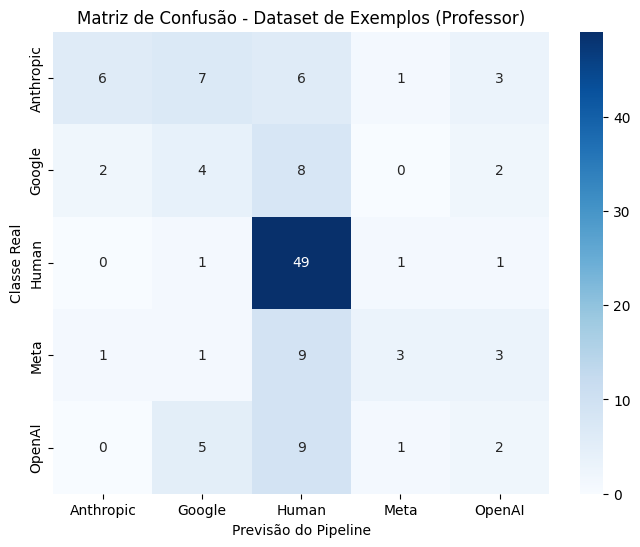

In [19]:
# Passo 5: Testar com dataset de exemplos

df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_exemplos = df_exemplos.dropna(subset=['Text', 'Label'])

X_ex = df_exemplos['Text']
y_ex = df_exemplos['Label']

print(f"\nA testar a pipeline com {len(X_ex)} exemplos inéditos do professor...")
preds_ex = pipeline_predict(X_ex, tfidf1, net1, tfidf2, net2, classes1, classes2)

acc_ex = accuracy_score(y_ex, preds_ex)
print(f"\nAccuracy no Dataset de Exemplos: {acc_ex*100:.2f}%")

cm_ex = confusion_matrix(y_ex, preds_ex, labels=all_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ex, annot=True, fmt='d', cmap='Blues', xticklabels=all_classes, yticklabels=all_classes)
plt.title('Matriz de Confusão - Dataset de Exemplos (Professor)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão do Pipeline')
plt.show()



AVALIAÇÃO INTERMÉDIA: MODELO 1 (HUMANO vs IA)
Accuracy Binária (Humano vs IA): 72.00%
MCC Binário (Humano vs IA):      0.5201

Relatório de Classificação Binário:
              precision    recall  f1-score   support

       Human       0.60      0.94      0.74        52
          IA       0.93      0.56      0.70        73

    accuracy                           0.72       125
   macro avg       0.77      0.75      0.72       125
weighted avg       0.80      0.72      0.72       125



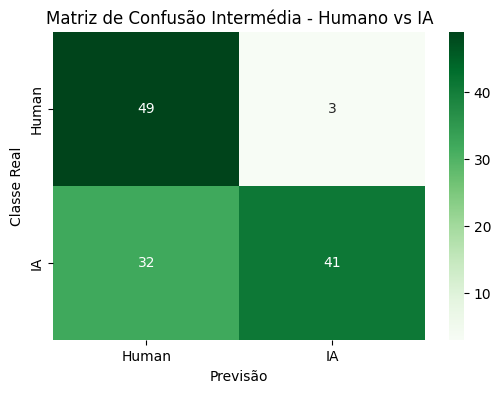

In [20]:
from sklearn.metrics import matthews_corrcoef, classification_report

print("\n" + "="*50)
print("AVALIAÇÃO INTERMÉDIA: MODELO 1 (HUMANO vs IA)")
print("="*50)

# 1. Converter as labels do dataset do professor para Binário ('Human' ou 'IA')
y_ex_bin = np.where(df_exemplos['Label'] == 'Human', 'Human', 'IA')

# 2. Vetorizar os textos do professor usando o TF-IDF do Modelo 1
X_ex_tfidf1 = tfidf1.transform(X_ex).toarray()

# Criar o Dataset temporário (o dummy_y é apenas para preencher o requisito da tua classe TextDataset)
dummy_y_ex1 = np.zeros((len(X_ex), len(classes1)))
ds_ex1 = TextDataset(X_ex_tfidf1, dummy_y_ex1)

# 3. Fazer as previsões APENAS na Rede 1
y_pred_prob_ex1 = net1.predict(ds_ex1)

# 4. Converter as probabilidades para as classes ('Human' ou 'IA')
preds_ex_bin = [classes1[np.argmax(p)] for p in y_pred_prob_ex1]

# 5. Calcular Accuracy e MCC
acc_bin = accuracy_score(y_ex_bin, preds_ex_bin)
mcc_bin = matthews_corrcoef(y_ex_bin, preds_ex_bin)

print(f"Accuracy Binária (Humano vs IA): {acc_bin*100:.2f}%")
print(f"MCC Binário (Humano vs IA):      {mcc_bin:.4f}")
print("\nRelatório de Classificação Binário:")
print(classification_report(y_ex_bin, preds_ex_bin))

# Opcional: Matriz de confusão da fase intermédia
cm_bin = confusion_matrix(y_ex_bin, preds_ex_bin, labels=['Human', 'IA'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens', xticklabels=['Human', 'IA'], yticklabels=['Human', 'IA'])
plt.title('Matriz de Confusão Intermédia - Humano vs IA')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.show()